In [3]:
# Core
import os
import importlib
import numpy as np
import pandas as pd
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Model / Feature selection / Scaling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.svm import SVC, LinearSVC

# Metrics

# Saving Model
import joblib


from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
# Metrics
# Saving Model
import joblib

from scipy.stats import loguniform, randint


In [4]:
svm = joblib.load("svm.pkl")
svm_irus = joblib.load("svm_irus.pkl")
svm_irus_Norway = joblib.load("svm_irus_Norway.pkl")
svm_irus_rfe = joblib.load("svm_irus_rfe.pkl")
svm_irus_rfe_Norway = joblib.load("svm_irus_rfe_Norway.pkl")
svm_Norway = joblib.load("svm_Norway.pkl")
svm_rfe = joblib.load("svm_rfe.pkl")
svm_rfe_Norway = joblib.load("svm_rfe_Norway.pkl")
svm_smote = joblib.load("svm_smote.pkl")
svm_smote_Norway = joblib.load("svm_smote_Norway.pkl")
svm_smote_rfe = joblib.load("svm_smote_rfe.pkl.pkl")  # note the double .pkl
svm_smote_rfe_Norway = joblib.load("svm_smote_rfe_Norway.pkl")

svm_purified = joblib.load("Purified/svm.pkl")
svm_irus_purified = joblib.load("Purified/svm_irus.pkl")
svm_irus_Norway_purified = joblib.load("Purified/svm_irus_Norway.pkl")
svm_irus_rfe_purified = joblib.load("Purified/svm_irus_rfe.pkl")
svm_irus_rfe_Norway_purified = joblib.load("Purified/svm_irus_rfe_Norway.pkl")
svm_Norway_purified = joblib.load("Purified/svm_Norway.pkl")
svm_rfe_purified = joblib.load("Purified/svm_rfe.pkl")
svm_rfe_Norway_purified = joblib.load("Purified/svm_rfe_Norway.pkl")
svm_smote_purified = joblib.load("Purified/svm_smote.pkl")
svm_smote_Norway_purified = joblib.load("Purified/svm_smote_Norway.pkl")
svm_smote_rfe_purified = joblib.load("Purified/svm_smote_rfe.pkl")
svm_smote_rfe_Norway_purified = joblib.load("Purified/svm_smote_rfe_Norway.pkl")

c:\Users\Public\Anaconda\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Public\Anaconda\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Public\Anaconda\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RFE from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. U

In [5]:
X_train = pd.read_csv('../Datasets/X_train.csv')
X_test  = pd.read_csv('../Datasets/X_test.csv')

y_train = pd.read_csv('../Datasets/Y_train.csv').squeeze("columns")  
y_test  = pd.read_csv('../Datasets/Y_test.csv').squeeze("columns")    # -> Series

X_train_Norway = pd.read_csv('../Datasets/X_train_Norway.csv')
X_test_Norway  = pd.read_csv('../Datasets/X_test_Norway.csv')

y_train_Norway = pd.read_csv('../Datasets/Y_train_Norway.csv').squeeze("columns")  
y_test_Norway  = pd.read_csv('../Datasets/Y_test_Norway.csv').squeeze("columns")    # -> Series

X_train_purified = pd.read_csv('../Datasets/X_train_purified.csv')
X_test_purified  = pd.read_csv('../Datasets/X_test_purified.csv')  
y_train_purified = pd.read_csv('../Datasets/Y_train_purified.csv').squeeze("columns")
y_test_purified  = pd.read_csv('../Datasets/Y_test_purified.csv').squeeze("columns")    # -> Series

X_train_Norway_purified = pd.read_csv('../Datasets/X_train_Norway_purified.csv')
X_test_Norway_purified  = pd.read_csv('../Datasets/X_test_Norway_purified.csv')
y_train_Norway_purified = pd.read_csv('../Datasets/Y_train_Norway_purified.csv').squeeze("columns")
y_test_Norway_purified  = pd.read_csv('../Datasets/Y_test_Norway_purified.csv').squeeze("columns")    # -> Series

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

def get_feature_names(model):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "steps"):
        for _, step in reversed(model.steps):
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)
    return None

def align_X(model, X):
    cols = get_feature_names(model)
    if cols is None:
        return X
    missing = [c for c in cols if c not in X.columns]
    if missing:
        raise ValueError(f"Missing {len(missing)} columns for model: {missing[:5]}...")
    return X.loc[:, cols]

def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    raise ValueError("Model has no predict_proba or decision_function.")

def get_classes(model):
    if hasattr(model, "classes_"):
        return model.classes_
    if hasattr(model, "steps"):
        for _, step in reversed(model.steps):
            if hasattr(step, "classes_"):
                return step.classes_
    raise ValueError("Model has no classes_.")

def plot_pr_curves(ax, model_entries, X_te, y_te, title):
    for name, model in model_entries:
        X_aligned = align_X(model, X_te)
        scores = get_scores(model, X_aligned)

        classes = get_classes(model)
        y_bin = label_binarize(y_te, classes=classes)

        if scores.ndim == 1:
            scores = scores.reshape(-1, 1)
            y_bin = y_bin.reshape(-1, 1)

        precision, recall, _ = precision_recall_curve(y_bin.ravel(), scores.ravel())
        ap = average_precision_score(y_bin, scores, average="micro")
        ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8, loc="lower left")

# Only include models that exist
def pick_models(names):
    return [(n, globals()[n]) for n in names if n in globals()]

tcga_models = pick_models([
    "svm", "svm_irus", "svm_irus_rfe", "svm_rfe", "svm_smote", "svm_smote_rfe"
])

norway_models = pick_models([
    "svm_Norway", "svm_irus_Norway", "svm_irus_rfe_Norway",
    "svm_rfe_Norway", "svm_smote_Norway", "svm_smote_rfe_Norway"
])

tcga_p_models = pick_models([
    "svm_purified", "svm_irus_purified", "svm_irus_rfe_purified",
    "svm_rfe_purified", "svm_smote_purified", "svm_smote_rfe_purified"
])

norway_p_models = pick_models([
    "svm_Norway_purified", "svm_irus_Norway_purified", "svm_irus_rfe_Norway_purified",
    "svm_rfe_Norway_purified", "svm_smote_Norway_purified", "svm_smote_rfe_Norway_purified"
])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_pr_curves(axes[0, 0], tcga_models, X_test, y_test, "TCGA (Non‑Purified)")
plot_pr_curves(axes[0, 1], norway_models, X_test_Norway, y_test_Norway, "Norway (Non‑Purified)")
plot_pr_curves(axes[1, 0], tcga_p_models, X_test_purified, y_test_purified, "TCGA (Purified)")
plot_pr_curves(axes[1, 1], norway_p_models, X_test_Norway_purified, y_test_Norway_purified, "Norway (Purified)")

plt.tight_layout()


In [6]:
def print_pr_auc(models, X_te, y_te, group_name):
    print(f"\n--- {group_name} ---")
    for name, model in models:
        X_aligned = align_X(model, X_te)
        scores = get_scores(model, X_aligned)

        classes = get_classes(model)
        y_bin = label_binarize(y_te, classes=classes)

        if scores.ndim == 1:
            scores = scores.reshape(-1, 1)
            y_bin = y_bin.reshape(-1, 1)

        ap = average_precision_score(y_bin, scores, average="micro")
        print(f"{name}: PR-AUC (AP) = {ap:.3f}")

print_pr_auc(tcga_models, X_test, y_test, "TCGA (Non‑Purified)")
print_pr_auc(norway_models, X_test_Norway, y_test_Norway, "Norway (Non‑Purified)")
print_pr_auc(tcga_p_models, X_test_purified, y_test_purified, "TCGA (Purified)")
print_pr_auc(norway_p_models, X_test_Norway_purified, y_test_Norway_purified, "Norway (Purified)")


NameError: name 'tcga_models' is not defined

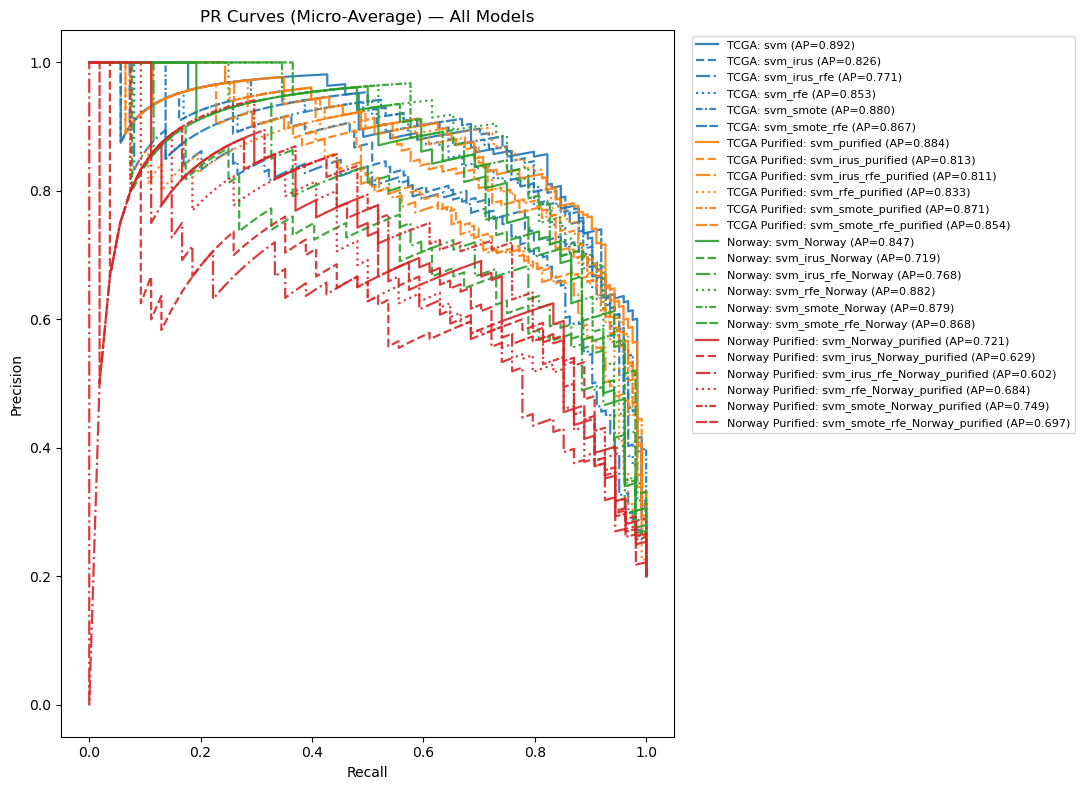

In [6]:
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

def plot_group(ax, group_name, model_entries, X_te, y_te, color):
    linestyles = itertools.cycle(["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1))])
    for name, model in model_entries:
        X_aligned = align_X(model, X_te)
        scores = get_scores(model, X_aligned)

        classes = get_classes(model)
        y_bin = label_binarize(y_te, classes=classes)

        if scores.ndim == 1:
            scores = scores.reshape(-1, 1)
            y_bin = y_bin.reshape(-1, 1)

        precision, recall, _ = precision_recall_curve(y_bin.ravel(), scores.ravel())
        ap = average_precision_score(y_bin, scores, average="micro")

        ax.plot(
            recall, precision,
            color=color,
            linestyle=next(linestyles),
            linewidth=1.6,
            alpha=0.9,
            label=f"{group_name}: {name} (AP={ap:.3f})"
        )

fig, ax = plt.subplots(figsize=(11, 8))

group_colors = {
    "TCGA": "tab:blue",
    "TCGA Purified": "tab:orange",
    "Norway": "tab:green",
    "Norway Purified": "tab:red",
}

groups = [
    ("TCGA", tcga_models, X_test, y_test),
    ("TCGA Purified", tcga_p_models, X_test_purified, y_test_purified),
    ("Norway", norway_models, X_test_Norway, y_test_Norway),
    ("Norway Purified", norway_p_models, X_test_Norway_purified, y_test_Norway_purified),
]

for gname, models, X_te, y_te in groups:
    plot_group(ax, gname, models, X_te, y_te, group_colors[gname])

ax.set_title("PR Curves (Micro‑Average) — All Models")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()


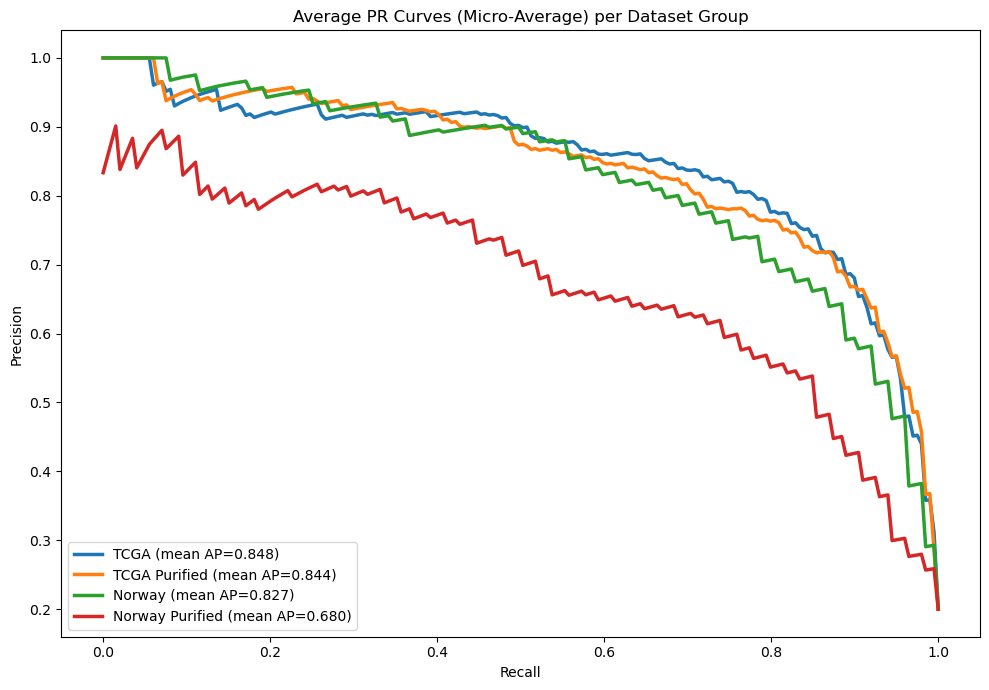

In [8]:

def pr_curve_micro(model, X, y):
    X_aligned = align_X(model, X)
    scores = get_scores(model, X_aligned)

    classes = get_classes(model)
    y_bin = label_binarize(y, classes=classes)

    if scores.ndim == 1:
        scores = scores.reshape(-1, 1)
        y_bin = y_bin.reshape(-1, 1)

    precision, recall, _ = precision_recall_curve(y_bin.ravel(), scores.ravel())
    ap = average_precision_score(y_bin, scores, average="micro")
    return precision, recall, ap

def avg_pr_curve(models, X, y, recall_grid=np.linspace(0, 1, 200)):
    prec_list = []
    ap_list = []
    for name, model in models:
        precision, recall, ap = pr_curve_micro(model, X, y)

        # ensure recall is increasing for interpolation
        if recall[0] > recall[-1]:
            recall = recall[::-1]
            precision = precision[::-1]

        prec_interp = np.interp(recall_grid, recall, precision)
        prec_list.append(prec_interp)
        ap_list.append(ap)

    mean_prec = np.mean(prec_list, axis=0)
    mean_ap = np.mean(ap_list)
    return recall_grid, mean_prec, mean_ap


group_colors = {
    "TCGA": "tab:blue",
    "TCGA Purified": "tab:orange",
    "Norway": "tab:green",
    "Norway Purified": "tab:red",
}

groups = [
    ("TCGA", tcga_models, X_test, y_test),
    ("TCGA Purified", tcga_p_models, X_test_purified, y_test_purified),
    ("Norway", norway_models, X_test_Norway, y_test_Norway),
    ("Norway Purified", norway_p_models, X_test_Norway_purified, y_test_Norway_purified),
]

plt.figure(figsize=(10, 7))

for gname, models, X_te, y_te in groups:
    rgrid, mean_prec, mean_ap = avg_pr_curve(models, X_te, y_te)
    plt.plot(rgrid, mean_prec, color=group_colors[gname],
             linewidth=2.5, label=f"{gname} (mean AP={mean_ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Average PR Curves (Micro‑Average) per Dataset Group")
plt.legend(loc="lower left")
plt.tight_layout()


In [ ]:
import shap
import numpy as np
import pandas as pd

model = svm
X = X_test  # DataFrame with gene columns

# use small background/eval sets for speed
bg = shap.sample(X, 100, random_state=0)
X_eval = shap.sample(X, 200, random_state=1)

def predict_fn(X_array):
    X_df = pd.DataFrame(X_array, columns=X.columns)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_df)
    return model.decision_function(X_df)

# Try fast LinearExplainer if possible, else use KernelExplainer
explainer = None
try:
    # works for linear models
    explainer = shap.LinearExplainer(model, bg, feature_perturbation="interventional")
    shap_vals = explainer.shap_values(X_eval)
except Exception:
    explainer = shap.KernelExplainer(predict_fn, bg.to_numpy())
    shap_vals = explainer.shap_values(X_eval.to_numpy(), nsamples=200)

# aggregate across classes
if isinstance(shap_vals, list):
    shap_arr = np.mean([np.abs(sv) for sv in shap_vals], axis=0)
else:
    shap_arr = np.abs(shap_vals)

mean_abs = shap_arr.mean(axis=0)

top20_idx = np.argsort(mean_abs)[::-1][:20]
top20_genes = pd.DataFrame({
    "gene": X.columns[top20_idx],
    "mean_abs_shap": mean_abs[top20_idx]
})

top20_genes


c:\Users\Public\Anaconda\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


  0%|          | 0/124 [00:00<?, ?it/s]